# Anomaly Detection Model: Autoencoder

This notebook trains a simple autoencoder using only normal UNSW-NB15 training traffic (`label == 0`). The fitted preprocessing pipeline is reused without refitting. A reconstruction-error threshold is calibrated from a held-out normal validation split, then the untouched test set is evaluated with accuracy, precision, recall, F1-score, ROC-AUC, and a confusion matrix.

This notebook covers only autoencoder anomaly detection. Zero-day detection, Federated Learning, SHAP/LIME, threat scoring, and the dashboard are intentionally out of scope.

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
project_root = Path.cwd().resolve()
for candidate in (project_root, project_root.parent):
    if (candidate / 'dataset' / 'UNSW-NB15').exists():
        project_root = candidate
        break

if not (project_root / 'dataset' / 'UNSW-NB15').exists():
    raise FileNotFoundError('Could not find dataset/UNSW-NB15 from the notebook or its parent folder.')

project_root = project_root.resolve()
data_dir = project_root / 'dataset' / 'UNSW-NB15'
model_dir = project_root / 'models' / 'trained_models'
results_dir = project_root / 'results' / 'plots'
model_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

train_path = data_dir / 'UNSW_NB15_training-set.csv'
test_path = data_dir / 'UNSW_NB15_testing-set.csv'
pipeline_path = project_root / 'models' / 'preprocessing_pipeline.pkl'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
with pipeline_path.open('rb') as file:
    preprocessor = pickle.load(file)

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'Pipeline: {type(preprocessor).__name__}')

Train shape: (175341, 45)
Test shape: (82332, 45)
Pipeline: ColumnTransformer


In [3]:
target_col = 'label'
feature_cols = [column for column in train_df.columns if column not in (target_col, 'attack_cat')]
X_train_raw = train_df[feature_cols]
X_test_raw = test_df[feature_cols]
y_train = train_df[target_col].astype(int).to_numpy()
y_test = test_df[target_col].astype(int).to_numpy()

X_train_processed = np.asarray(preprocessor.transform(X_train_raw), dtype=np.float32)
X_test_processed = np.asarray(preprocessor.transform(X_test_raw), dtype=np.float32)

normal_training = X_train_processed[y_train == 0]
X_fit, X_calibration = train_test_split(
    normal_training,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)

print(f'Processed feature count: {X_train_processed.shape[1]}')
print(f'Normal training samples: {len(normal_training)}')
print(f'Autoencoder fit samples: {len(X_fit)}')
print(f'Threshold calibration samples: {len(X_calibration)}')
print(f'Test labels: {np.bincount(y_test)}')

Processed feature count: 195
Normal training samples: 56000
Autoencoder fit samples: 44800
Threshold calibration samples: 11200
Test labels: [37000 45332]


In [4]:
input_dim = X_fit.shape[1]
latent_dim = min(32, max(4, input_dim // 4))

autoencoder = keras.Sequential(
    [
        keras.Input(shape=(input_dim,), name='features'),
        layers.Dense(64, activation='relu', name='encoder'),
        layers.Dense(latent_dim, activation='relu', name='latent'),
        layers.Dense(64, activation='relu', name='decoder'),
        layers.Dense(input_dim, activation='linear', name='reconstruction'),
    ],
    name='unsw_nb15_autoencoder',
)
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
autoencoder.summary()

Model: "unsw_nb15_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Dense)                 │ (None, 64)             │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 195)            │        12,675 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,411 (114.89 KB)

 Trainable params: 29,411 (114.89 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)
history = autoencoder.fit(
    X_fit,
    X_fit,
    validation_data=(X_calibration, X_calibration),
    epochs=20,
    batch_size=256,
    shuffle=True,
    callbacks=[early_stopping],
    verbose=0,
)

print(f'Epochs trained: {len(history.history["loss"])}')
print(f'Best validation loss: {min(history.history["val_loss"]):.6f}')

Epochs trained: 20
Best validation loss: 0.000671


In [6]:
def reconstruction_error(features):
    reconstructed = autoencoder.predict(features, batch_size=1024, verbose=0)
    return np.mean(np.square(features - reconstructed), axis=1)

calibration_errors = reconstruction_error(X_calibration)
test_errors = reconstruction_error(X_test_processed)

# The threshold uses only normal data excluded from model fitting and never uses test labels.
anomaly_threshold = float(np.percentile(calibration_errors, 95))
y_test_pred = (test_errors > anomaly_threshold).astype(int)

print(f'Calibration error 95th percentile threshold: {anomaly_threshold:.6f}')
print(f'Predicted normal: {(y_test_pred == 0).sum()}')
print(f'Predicted anomaly: {(y_test_pred == 1).sum()}')

Calibration error 95th percentile threshold: 0.001948
Predicted normal: 45328
Predicted anomaly: 37004


In [7]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, test_errors)
cm = confusion_matrix(y_test, y_test_pred)

metrics = pd.Series(
    {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
    }
)
print(metrics.to_string(float_format=lambda value: f'{value:.4f}'))
print('\nConfusion matrix (rows=true, columns=predicted):')
print(cm)

accuracy    0.8163
precision   0.9082
recall      0.7413
f1_score    0.8163
roc_auc     0.8825

Confusion matrix (rows=true, columns=predicted):
[[33602  3398]
 [11726 33606]]


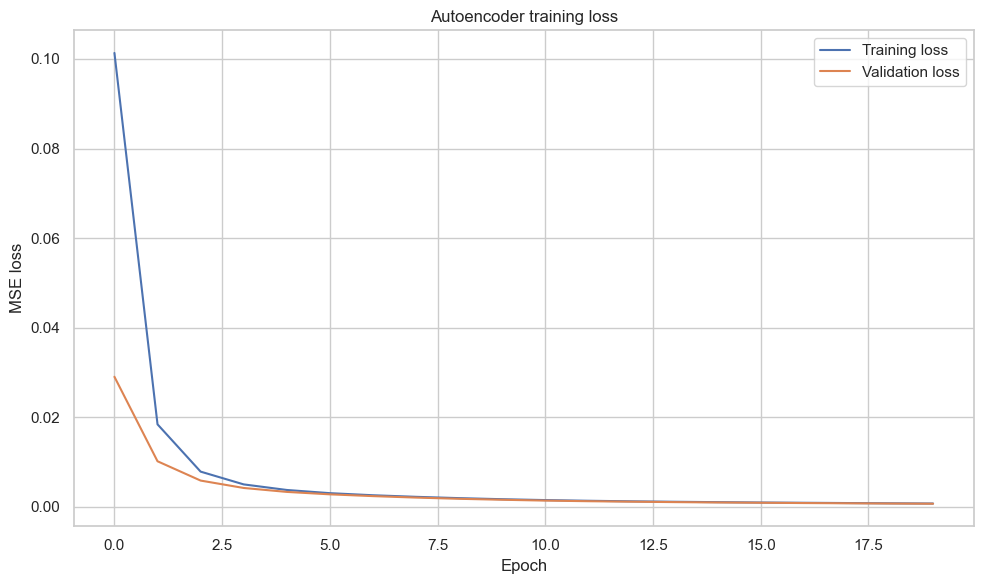

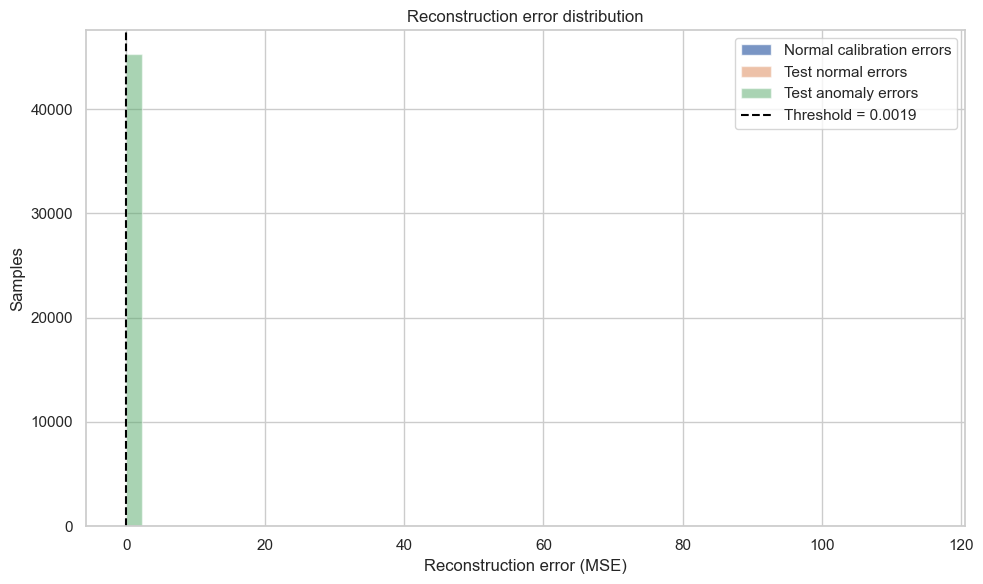

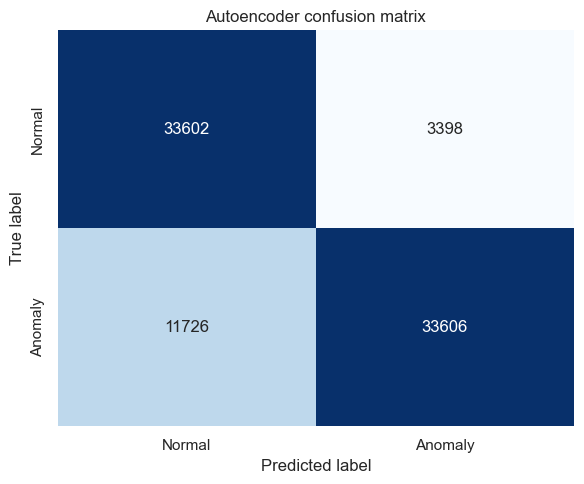

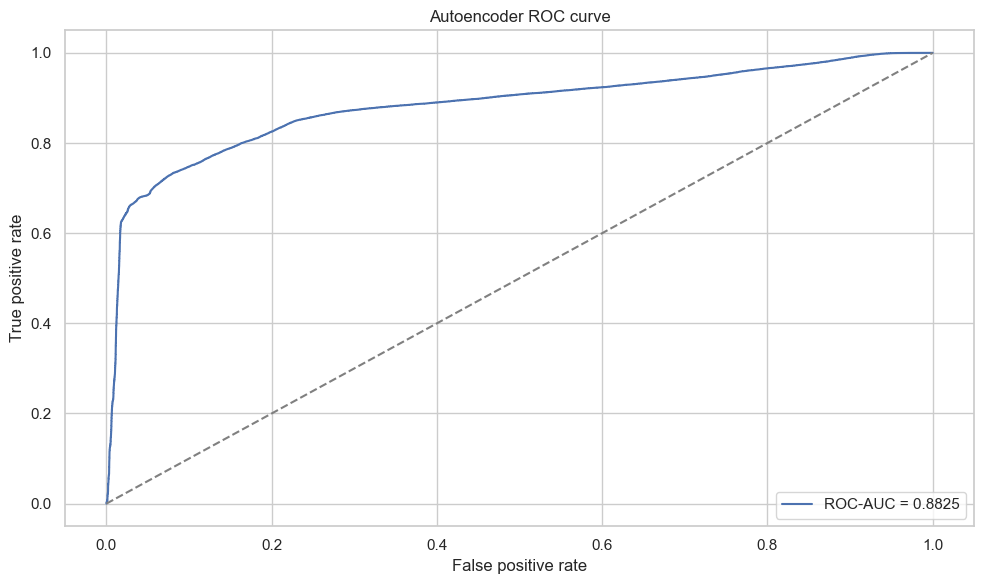

Plots saved in C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\results\plots


In [8]:
fig, ax = plt.subplots()
ax.plot(history.history['loss'], label='Training loss')
ax.plot(history.history['val_loss'], label='Validation loss')
ax.set(xlabel='Epoch', ylabel='MSE loss', title='Autoencoder training loss')
ax.legend()
fig.tight_layout()
fig.savefig(results_dir / '03_autoencoder_training_loss.png', dpi=200)
plt.show()

fig, ax = plt.subplots()
ax.hist(calibration_errors, bins=50, alpha=0.75, label='Normal calibration errors')
ax.hist(test_errors[y_test == 0], bins=50, alpha=0.5, label='Test normal errors')
ax.hist(test_errors[y_test == 1], bins=50, alpha=0.5, label='Test anomaly errors')
ax.axvline(anomaly_threshold, color='black', linestyle='--', label=f'Threshold = {anomaly_threshold:.4f}')
ax.set(xlabel='Reconstruction error (MSE)', ylabel='Samples', title='Reconstruction error distribution')
ax.legend()
fig.tight_layout()
fig.savefig(results_dir / '03_reconstruction_error_distribution.png', dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
ax.set(xlabel='Predicted label', ylabel='True label', title='Autoencoder confusion matrix')
fig.tight_layout()
fig.savefig(results_dir / '03_confusion_matrix.png', dpi=200)
plt.show()

fpr, tpr, _ = roc_curve(y_test, test_errors)
fig, ax = plt.subplots()
ax.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set(xlabel='False positive rate', ylabel='True positive rate', title='Autoencoder ROC curve')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(results_dir / '03_roc_curve.png', dpi=200)
plt.show()

print(f'Plots saved in {results_dir}')

In [9]:
model_path = model_dir / 'autoencoder_model.h5'
autoencoder.save(model_path)

artifacts = {
    'anomaly_threshold': anomaly_threshold,
    'threshold_percentile': 95,
    'input_dim': input_dim,
    'latent_dim': latent_dim,
    'feature_columns': feature_cols,
}
with (model_dir / 'autoencoder_threshold.pkl').open('wb') as file:
    pickle.dump(artifacts, file)

metrics.to_csv(results_dir / '03_autoencoder_metrics.csv', header=['value'])
print(f'Model saved to: {model_path}')
print(f'Threshold metadata saved to: {model_dir / "autoencoder_threshold.pkl"}')
print(f'Metrics saved to: {results_dir / "03_autoencoder_metrics.csv"}')

Model saved to: C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\models\trained_models\autoencoder_model.h5
Threshold metadata saved to: C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\models\trained_models\autoencoder_threshold.pkl
Metrics saved to: C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\results\plots\03_autoencoder_metrics.csv
